In [5]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
    print(f"Current CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA is available: True
CUDA version PyTorch was built with: 12.4
Current CUDA device name: NVIDIA L4


In [6]:
!pip install koreanize-matplotlib sdv catboost -q

In [7]:
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta
from bisect import bisect_left, bisect_right

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# SDV (데이터 증강) 라이브러리
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# 전처리 및 모델링 라이브러리
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# 평가 라이브러리
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

import warnings
try:
    import koreanize_matplotlib
except ImportError:
    pass
warnings.filterwarnings('ignore')

In [8]:
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/거래_이상탐지_프로젝트/data'

Mounted at /content/drive/


In [9]:
train_df = pd.read_csv(path+"/fraudTrain.csv")
test_df = pd.read_csv(path+"/fraudTest.csv")

In [10]:
def calculate_age(born, trans_date):
    return relativedelta(trans_date, born).years

def count_past_days_fast(df, days):
    results = []
    grouped = df.groupby('cc_num')

    for card, group in grouped:
        times = group['trans_date_trans_time'].tolist()
        counts = []
        for i, t in enumerate(times):
            start_time = t - pd.Timedelta(days=days)
            # 왼쪽 경계 (start_time 이상)
            left_idx = bisect_left(times, start_time)
            # 오른쪽 경계는 현재 거래 바로 전(i번째 거래 제외)
            right_idx = i
            counts.append(right_idx - left_idx)
        results.extend(counts)
    return results

def preprocess_data(df: pd.DataFrame,
                    hour: str = 'sincos',
                    high_risk_period: bool = False,
                    age_group: bool = False
                    ) -> pd.DataFrame:
    '''
    Arg)
    df : 데이터프레임
    hour : 시간 전처리방법 (sincos : sin/cos 변환 , is_night : 'is_night' 칼럼 사용)
    high_risk_period : high_risk_period 사용여부 (Default : False)
    age_group : age_group 사용여부 (Default : False)
    '''

    # 원본 데이터프레임 복사
    df_p = df.copy()

    drop_cols = ['Unnamed: 0', 'unix_time', 'trans_num', 'first', 'last', 'merchant', 'street', 'merch_lat', 'merch_long', 'city_pop', 'lat', 'long', 'zip']
    df_p = df_p.drop(columns=drop_cols)

    # 로그 변환
    df_p['amt_log'] = np.log1p(df_p['amt'])

    # 표준화
    scaler = StandardScaler()
    df_p['amt_log_std'] = scaler.fit_transform(df_p[['amt_log']])

    # datetime 변환
    df_p['datetime'] = pd.to_datetime(df_p['trans_date_trans_time'])

    # 시(hour) 추출 (0~23)
    df_p['hour'] = df_p['datetime'].dt.hour

    # 요일 추출: Monday=0, Sunday=6
    df_p['day_of_week'] = df_p['datetime'].dt.dayofweek

    # 월 추출: 1월=1, 12월=12
    df_p['month'] = df_p['datetime'].dt.month

    # Hour : SinCos변환 or Is_night 사용
    if hour == 'sincos':
        df_p['trans_hour_sin'] = np.sin(2 * np.pi * df_p['hour'] / 24)
        df_p['trans_hour_cos'] = np.cos(2 * np.pi * df_p['hour'] / 24)
    elif hour == 'is_night':
        df_p['is_night'] = df_p['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)


    # higt_rist_period 사용여부
    if high_risk_period:
        # 금(4), 목(3), 수(2) + 심야 시간대(0~4, 21~23)
        high_risk_days = [2, 3, 4]  # 수, 목, 금
        high_risk_hours = list(range(0, 5)) + [21, 22, 23]

        df_p['is_high_risk_period'] = (
            df_p['day_of_week'].isin(high_risk_days) & df_p['hour'].isin(high_risk_hours)
        ).astype(int)

    df_p['trans_date_trans_time'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p = df_p.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    df_p['cnt_1d'] = count_past_days_fast(df_p, 1)
    df_p['cnt_7d'] = count_past_days_fast(df_p, 7)
    df_p['cnt_30d'] = count_past_days_fast(df_p, 30)

    df_p['next_trans_time'] = df_p.groupby('cc_num')['trans_date_trans_time'].shift(-1)
    df_p['time_since_last_trans'] = (df_p['trans_date_trans_time'] - df_p.groupby('cc_num')['trans_date_trans_time'].shift(1)).dt.total_seconds()

    # 또는 마지막 거래 이후 경과 시간(다음 거래까지 시간 간격)
    df_p['time_until_next_trans'] = (df_p['next_trans_time'] - df_p['trans_date_trans_time']).dt.total_seconds()

    # 결측치 처리 (time_since_last_trans 첫 거래는 NaN, 0으로 채우거나 다른 방식)
    df_p[['time_since_last_trans', 'time_until_next_trans']] = df_p[['time_since_last_trans', 'time_until_next_trans']].fillna(0)


    df_p['dob'] = pd.to_datetime(df_p['dob'])

    df_p['age'] = df_p.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)

    if age_group:
        df_p['age_group'] = (df_p['age'] // 10) * 10
        df_p = df_p.drop(columns=['age'])


    # Job 칼럼 Target Encoding + Smoothing ( 아직 없음 )

    df_p['city_state'] = df_p['city'] + ', ' + df_p['state']

    # 최종 Drop
    drop_cols = ['trans_date_trans_time', 'dob', 'next_trans_time', 'cc_num', 'datetime', 'time_until_next_trans', 'city', 'state', 'amt', 'amt_log', 'hour']
    df_p = df_p.drop(columns=drop_cols)

    return df_p

In [11]:
# K-Fold, 타겟 인코딩 스무딩 함수
def m_estimate_smoothing(mean, global_mean, count, m):
    """M-estimate 스무딩을 적용하여 평균을 계산합니다."""
    return (mean * count + global_mean * m) / (count + m)

def kfold_target_encoding(df, target_col, cat_cols, n_splits=5, m_param=10):
    """
    K-Fold 교차 검증 방식의 타겟 인코딩을 M-estimate 스무딩과 함께 적용합니다.
    주어진 cat_cols 리스트에 있는 모든 컬럼에 대해 OOF 인코딩을 적용하고,
    각 컬럼에 대한 Full 인코딩 맵과 전역 평균을 반환합니다.

    Args:
        df: 입력 데이터프레임 (훈련 데이터).
        target_col: 타겟 컬럼 이름 (예: 'is_fraud').
        cat_cols: 인코딩하고 값을 덮어쓸 범주형 컬럼 이름의 리스트.
        n_splits: K-Fold 분할 개수.
        m_param: M-estimate 스무딩 파라미터.
    Returns:
        tuple: (OOF 인코딩된 DataFrame, 각 컬럼별 Full 인코딩 맵과 전역 평균을 담은 딕셔너리)
    """
    df_processed = df.copy() # 원본 DataFrame을 직접 수정하지 않기 위해 복사본 사용
    global_mean = df_processed[target_col].mean() # 전체 타겟 변수의 평균 (모든 인코딩에 공통 사용)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 각 범주형 컬럼별로 학습된 Full 인코딩 맵과 전역 평균을 저장할 딕셔너리
    all_learned_encoding_info = {}

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols: # 각 범주형 컬럼에 대해 반복 처리
        print(f"--- '{cat_col}' 컬럼 OOF 인코딩 진행 중 ---")
        temp_oof_encoded_values = np.empty(len(df_processed))
        temp_oof_encoded_values[:] = np.nan # 초기화

        for train_idx, valid_idx in kf.split(df_processed):
            train_fold = df_processed.iloc[train_idx]

            # 훈련 폴드에서 해당 cat_col의 평균 및 개수 집계
            agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()

            # M-estimate 스무딩 적용
            agg['smoothed'] = m_estimate_smoothing(agg['mean'], global_mean, agg['count'], m_param)
            mapping = dict(zip(agg[cat_col], agg['smoothed']))

            # 유효성 검사 폴드의 해당 cat_col 위치에 스무딩된 값을 매핑
            temp_oof_encoded_values[valid_idx] = df_processed.loc[valid_idx, cat_col].map(mapping).fillna(global_mean)

        # 모든 폴드에 대한 처리가 끝난 후, df_processed에 OOF 인코딩된 값을 덮어씁니다.
        df_processed[cat_col] = temp_oof_encoded_values

        # 현재 컬럼에 대한 Full 인코딩 맵 생성 (테스트 데이터 인코딩에 사용될 예정)
        full_agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
        full_agg['smoothed'] = m_estimate_smoothing(full_agg['mean'], global_mean, full_agg['count'], m_param)
        full_encoding_map = dict(zip(full_agg[cat_col], full_agg['smoothed']))

        # 각 컬럼의 맵과 전역 평균을 딕셔너리에 저장
        all_learned_encoding_info[cat_col] = {
            'map': full_encoding_map,
            'global_mean': global_mean # 각 컬럼별 전역 평균은 동일
        }

    return df_processed, all_learned_encoding_info # OOF 인코딩된 DF와 모든 Full 맵/전역 평균 정보 반환


def test_data_target_encoding(df, cat_cols, learned_encoding_info):
    """
    제공된 인코딩 맵과 전역 평균을 사용하여 테스트 데이터프레임의 여러 컬럼을 인코딩합니다.

    Args:
        df: 입력 데이터프레임 (테스트 데이터).
        cat_cols: 인코딩할 범주형 컬럼 이름의 리스트.
        learned_encoding_info: kfold_target_encoding에서 반환된 학습된 인코딩 정보를 담은 딕셔너리.
                               예: {'col1': {'map': map1, 'global_mean': gm1}, 'col2': {'map': map2, 'global_mean': gm2}}
    Returns:
        인코딩된 컬럼이 덮어씌워진 DataFrame.
    """
    df_processed = df.copy()

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols:
        if cat_col not in learned_encoding_info:
            print(f"경고: '{cat_col}' 컬럼에 대한 학습된 인코딩 정보가 없습니다. 해당 컬럼은 인코딩되지 않습니다.")
            continue

        encoding_map = learned_encoding_info[cat_col]['map']
        global_mean = learned_encoding_info[cat_col]['global_mean']

        # 인코딩 값 덮어쓰기: 맵에 없는 값은 해당 컬럼의 전역 평균으로 대체
        df_processed[cat_col] = df_processed[cat_col].map(encoding_map).fillna(global_mean)
        print(f"--- '{cat_col}' 컬럼 테스트 데이터 인코딩 완료 ---")

    return df_processed

In [12]:
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = test_df.copy()
print("데이터 분할 완료")
print(f"학습: {df_train.shape}, 검증: {df_val.shape}, 테스트: {df_test.shape}\n" + "-"*50)

데이터 분할 완료
학습: (1037340, 23), 검증: (259335, 23), 테스트: (555719, 23)
--------------------------------------------------


In [13]:
print("1차 기본 전처리 시작...")
# preprocess_data 함수가 이미 정의되어 있다고 가정합니다.
train_temp = preprocess_data(df_train, high_risk_period=True, age_group=False)
val_temp = preprocess_data(df_val, high_risk_period=True, age_group=False)
test_temp = preprocess_data(df_test, high_risk_period=True, age_group=False)
print("-> 1차 기본 전처리 완료.")

1차 기본 전처리 시작...
-> 1차 기본 전처리 완료.


In [14]:
print("\nK-Fold 타겟 인코딩 (Smoothing) 시작...")

encoding_features = ['job', 'city_state']
m_param_job = 500
m_param_city_state = 5
n_splits_kfold = 5

train_encoded, learned_info_job = kfold_target_encoding(
    df=train_temp, target_col='is_fraud', cat_cols=['job'],
    n_splits=n_splits_kfold, m_param=m_param_job
)
train_encoded, learned_info_cs = kfold_target_encoding(
    df=train_encoded, target_col='is_fraud', cat_cols=['city_state'],
    n_splits=n_splits_kfold, m_param=m_param_city_state
)

learned_info = {**learned_info_job, **learned_info_cs}

val_encoded = test_data_target_encoding(df=val_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)
test_encoded = test_data_target_encoding(df=test_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)

rename_dict = {'job': 'job_encoded', 'city_state': 'city_state_encoded'}
train_encoded.rename(columns=rename_dict, inplace=True)
val_encoded.rename(columns=rename_dict, inplace=True)
test_encoded.rename(columns=rename_dict, inplace=True)

print(f"\n-> 타겟 인코딩 완료: {list(rename_dict.values())}")


K-Fold 타겟 인코딩 (Smoothing) 시작...
--- 'job' 컬럼 OOF 인코딩 진행 중 ---
--- 'city_state' 컬럼 OOF 인코딩 진행 중 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---

-> 타겟 인코딩 완료: ['job_encoded', 'city_state_encoded']


In [15]:
print("\nCTGAN 데이터 증강 시작...")

# 타겟 인코딩만 완료된 학습 데이터로 증강 수행
fraud_data = train_encoded[train_encoded['is_fraud'] == 1]
non_fraud_data = train_encoded[train_encoded['is_fraud'] == 0]

if len(fraud_data) > 0:
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(data=fraud_data)

    # 주의: 이 단계에서는 아직 원핫 인코딩이 되지 않았으므로,
    # 'category'와 'gender'는 CTGAN이 자동으로 'categorical'로 처리하도록 둡니다.
    metadata.update_column(column_name='job_encoded', sdtype='numerical')
    metadata.update_column(column_name='city_state_encoded', sdtype='numerical')

    synthesizer = CTGANSynthesizer(metadata, epochs=300, verbose=False)
    synthesizer.fit(fraud_data)
    synthetic_fraud_data = synthesizer.sample(num_rows=55000)

    # 증강된 데이터와 원본 데이터를 합쳐 새로운 학습 데이터셋 생성
    train_aug = pd.concat([non_fraud_data, fraud_data, synthetic_fraud_data], ignore_index=True)
    train_aug = train_aug.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"-> 데이터 증강 완료 (최종 학습 데이터: {train_aug.shape})")
else:
    print("-> 학습 데이터에 사기 거래가 없어 증강을 건너뜁니다.")
    train_aug = train_encoded

# 검증 및 테스트 데이터는 이 단계에서 변경 없이 그대로 전달
val_pre_ohe = val_encoded
test_pre_ohe = test_encoded


CTGAN 데이터 증강 시작...
-> 데이터 증강 완료 (최종 학습 데이터: (1092340, 16))


In [16]:
print("\n원-핫 인코딩 시작...\n")
categorical_features = ['category', 'gender','day_of_week','is_high_risk_period']

train_final_base = pd.get_dummies(train_aug, columns=categorical_features, dummy_na=False, drop_first=True)
val_final_base = pd.get_dummies(val_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)
test_final_base = pd.get_dummies(test_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)

train_cols = train_final_base.columns
val_final_base = val_final_base.reindex(columns=train_cols, fill_value=0)
test_final_base = test_final_base.reindex(columns=train_cols, fill_value=0)

print("-> 원-핫 인코딩 및 컬럼 정렬 완료.\n")


원-핫 인코딩 시작...

-> 원-핫 인코딩 및 컬럼 정렬 완료.



In [17]:
train_final_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092340 entries, 0 to 1092339
Data columns (total 33 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   job_encoded              1092340 non-null  float64
 1   is_fraud                 1092340 non-null  int64  
 2   amt_log_std              1092340 non-null  float64
 3   month                    1092340 non-null  int32  
 4   trans_hour_sin           1092340 non-null  float64
 5   trans_hour_cos           1092340 non-null  float64
 6   cnt_1d                   1092340 non-null  int64  
 7   cnt_7d                   1092340 non-null  int64  
 8   cnt_30d                  1092340 non-null  int64  
 9   time_since_last_trans    1092340 non-null  float64
 10  age                      1092340 non-null  int64  
 11  city_state_encoded       1092340 non-null  float64
 12  category_food_dining     1092340 non-null  bool   
 13  category_gas_transport   1092340 non-null 

## 모델 평가 시각화

In [18]:
def evaluate_and_visualize(model, X_data, y_data, set_name, bootstrap_val):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1] # ROC AUC 계산을 위해 추가

    # 결과를 딕셔너리로 저장
    results = {
        'F1-Score': f1_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred)
    }

    print(f"\\n--- {set_name} 평가 결과 (bootstrap={bootstrap_val}) ---")
    print(pd.DataFrame([results]).to_string())
    print("\\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    # 혼동 행렬 시각화 (파일로 저장)
    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name} | bootstrap={bootstrap_val})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    # 시각화 결과를 파일로 저장합니다.
    plt.savefig(f"confusion_matrix_{set_name.replace(' ', '_')}_bootstrap_{bootstrap_val}.png")
    plt.close() # 노트북에 바로 표시되지 않도록 닫습니다.

    return results

# isolation bootstrap 실험

In [19]:
# 결과를 저장할 리스트
results_list = []

# 비교할 bootstrap 옵션
bootstrap_options = [True, False]

for bootstrap_val in bootstrap_options:
    print(f"\\n===== bootstrap={bootstrap_val} 설정으로 실험 시작 =====")

    # 1. Isolation Forest를 사용한 피처 생성
    numeric_cols_for_iso = train_final_base.select_dtypes(include=np.number).drop(columns=['is_fraud']).columns.tolist()

    scaler_iso = StandardScaler()
    X_train_num_scaled_iso = scaler_iso.fit_transform(train_final_base[numeric_cols_for_iso])
    X_val_num_scaled_iso = scaler_iso.transform(val_final_base[numeric_cols_for_iso])
    X_test_num_scaled_iso = scaler_iso.transform(test_final_base[numeric_cols_for_iso])

    if_params = {
        'n_estimators': 200,
        'max_samples': 0.2,
        'max_features': 1.0,
        'contamination': 0.01,
        'bootstrap': bootstrap_val, # 실험 변수 적용
        'random_state': 42,
        'n_jobs': -1
    }

    print(f"Isolation Forest 모델 학습 중 (파라미터: {if_params})...")
    iso_model = IsolationForest(**if_params)
    iso_model.fit(X_train_num_scaled_iso)

    # 각 데이터셋에 iforest 피처 추가
    train_df_with_if = train_final_base.copy()
    val_df_with_if = val_final_base.copy()
    test_df_with_if = test_final_base.copy()

    for df, scaled_data in [(train_df_with_if, X_train_num_scaled_iso),
                            (val_df_with_if, X_val_num_scaled_iso),
                            (test_df_with_if, X_test_num_scaled_iso)]:
        df['iforest_score'] = iso_model.decision_function(scaled_data)
        df['iforest_outlier'] = iso_model.predict(scaled_data).astype(int)
        df['iforest_outlier'] = df['iforest_outlier'].map({1: 0, -1: 1})

    print("-> Isolation Forest 피처 추가 완료.")

    # 2. 최종 데이터셋 준비
    X_train_final = train_df_with_if.drop('is_fraud', axis=1)
    y_train_final = train_df_with_if['is_fraud']

    X_val_final = val_df_with_if.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
    y_val_final = val_df_with_if['is_fraud']

    X_test_final = test_df_with_if.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
    y_test_final = test_df_with_if['is_fraud']

    # iforest_score 피처 스케일링
    scaler_stacking = StandardScaler()

    X_train_scaled = X_train_final.copy()
    X_val_scaled = X_val_final.copy()
    X_test_scaled = X_test_final.copy()

    X_train_scaled['iforest_score'] = scaler_stacking.fit_transform(X_train_scaled[['iforest_score']])
    X_val_scaled['iforest_score'] = scaler_stacking.transform(X_val_scaled[['iforest_score']])
    X_test_scaled['iforest_score'] = scaler_stacking.transform(X_test_scaled[['iforest_score']])

    # 3. 스태킹 모델 학습
    print("\\n===== 스태킹(Stacking) 앙상블 모델 학습 시작 =====")
    lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1)
    xgb_clf = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
    cat_clf = CatBoostClassifier(random_state=42, verbose=0)
    meta_clf = LogisticRegression(random_state=42, n_jobs=-1)

    stacking_model = StackingClassifier(
        estimators=[('lgbm', lgbm_clf), ('xgb', xgb_clf), ('cat', cat_clf)],
        final_estimator=meta_clf,
        cv=3, # CV=3으로 설정하여 시간 단축 (원래 코드에서는 5였습니다)
        n_jobs=-1
    )

    stacking_model.fit(X_train_scaled, y_train_final)

    # 4. 평가 및 결과 저장
    val_results = evaluate_and_visualize(stacking_model, X_val_scaled, y_val_final, "Validation Set", bootstrap_val)
    test_results = evaluate_and_visualize(stacking_model, X_test_scaled, y_test_final, "Test Set", bootstrap_val)

    # 최종 결과를 리스트에 추가
    results_list.append({
        'bootstrap': bootstrap_val,
        'val_f1': val_results['F1-Score'],
        'val_recall': val_results['Recall'],
        'test_f1': test_results['F1-Score'],
        'test_recall': test_results['Recall']
    })

# --- 최종 결과 출력 ---
results_df = pd.DataFrame(results_list)
print("\\n\\n===== 최종 비교 결과 =====\\n")
print(results_df)

\n===== bootstrap=True 설정으로 실험 시작 =====
Isolation Forest 모델 학습 중 (파라미터: {'n_estimators': 200, 'max_samples': 0.2, 'max_features': 1.0, 'contamination': 0.01, 'bootstrap': True, 'random_state': 42, 'n_jobs': -1})...
-> Isolation Forest 피처 추가 완료.
\n===== 스태킹(Stacking) 앙상블 모델 학습 시작 =====
\n--- Validation Set 평가 결과 (bootstrap=True) ---
   F1-Score    Recall
0  0.875902  0.808794
\nClassification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9993    257834
           1     0.9552    0.8088    0.8759      1501

    accuracy                         0.9987    259335
   macro avg     0.9770    0.9043    0.9376    259335
weighted avg     0.9986    0.9987    0.9986    259335

\n--- Test Set 평가 결과 (bootstrap=True) ---
   F1-Score    Recall
0  0.607587  0.477855
\nClassification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9996    0.9988    553574
           1     0.8340    0.4779    0.6076      2

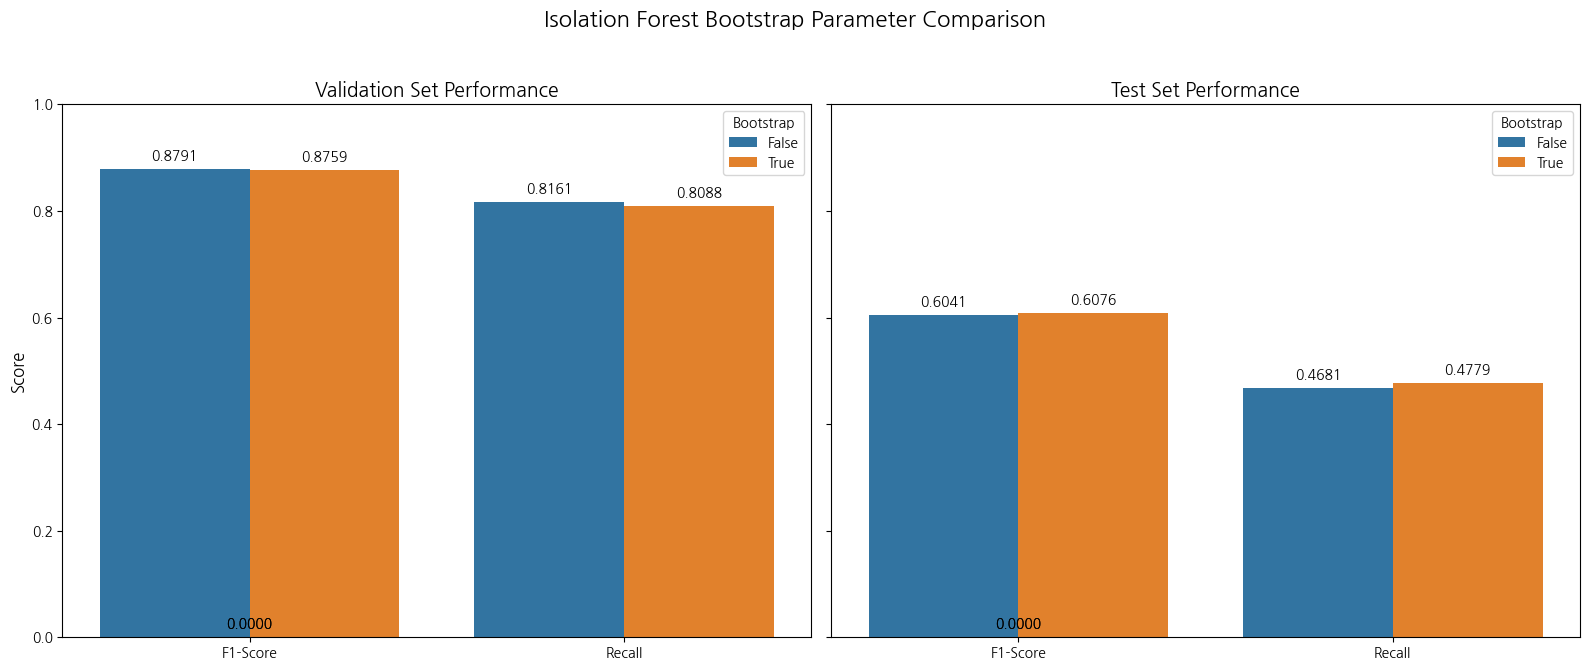

In [20]:
# 위에서 생성된 results_df를 사용하여 시각화합니다.
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Isolation Forest Bootstrap Parameter Comparison', fontsize=16)

# Validation 데이터셋 성능 플롯
val_df_to_plot = results_df[['bootstrap', 'val_f1', 'val_recall']].copy()
val_df_to_plot.rename(columns={'val_f1': 'F1-Score', 'val_recall': 'Recall'}, inplace=True)
val_melted = val_df_to_plot.melt(id_vars='bootstrap', var_name='Metric', value_name='Score')

sns.barplot(x='Metric', y='Score', hue='bootstrap', data=val_melted, ax=axes[0])
axes[0].set_title('Validation Set Performance', fontsize=14)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Bootstrap')

# 막대 위에 값 표시
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

# Test 데이터셋 성능 플롯
test_df_to_plot = results_df[['bootstrap', 'test_f1', 'test_recall']].copy()
test_df_to_plot.rename(columns={'test_f1': 'F1-Score', 'test_recall': 'Recall'}, inplace=True)
test_melted = test_df_to_plot.melt(id_vars='bootstrap', var_name='Metric', value_name='Score')

sns.barplot(x='Metric', y='Score', hue='bootstrap', data=test_melted, ax=axes[1])
axes[1].set_title('Test Set Performance', fontsize=14)
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].legend(title='Bootstrap')

# 막대 위에 값 표시
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# 생성된 플롯을 파일로 저장합니다.
# plt.savefig("bootstrap_comparison_plot.png")
plt.show()

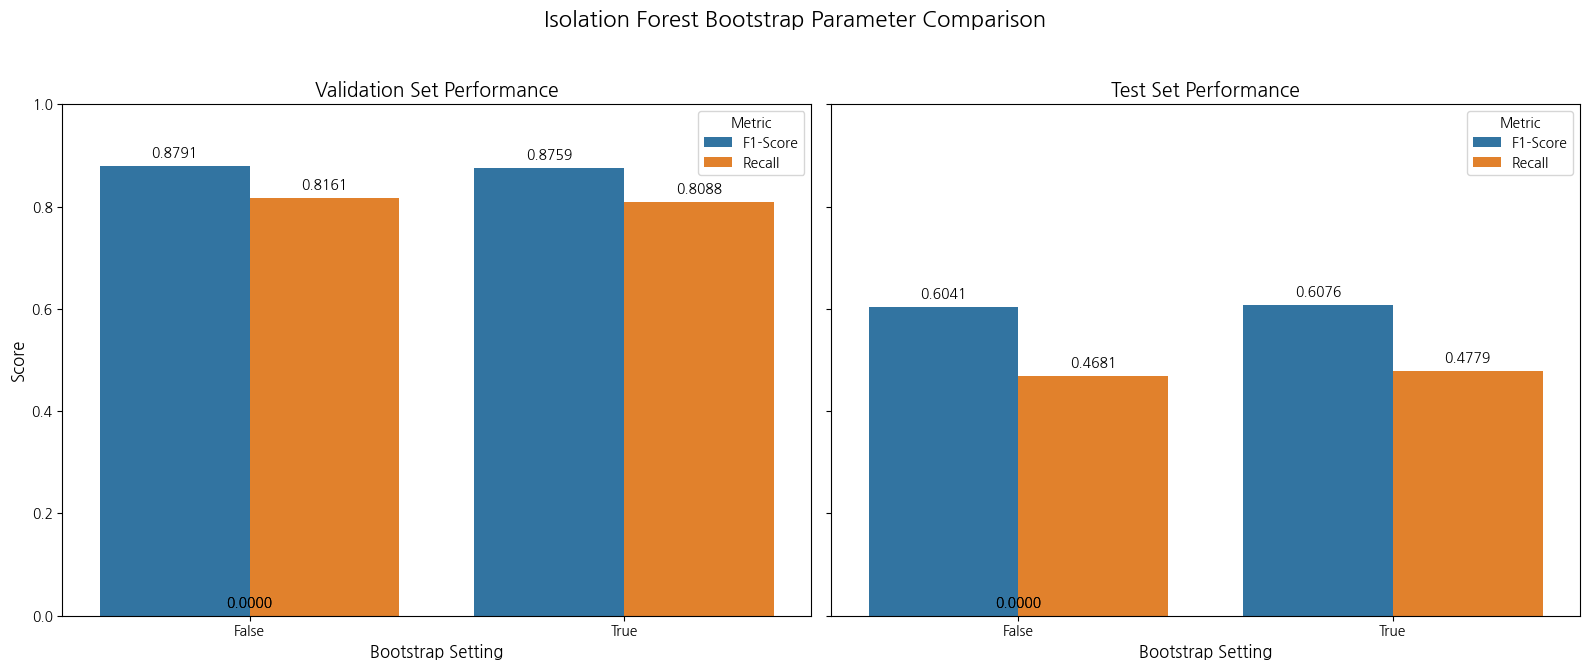

In [21]:
# 위에서 생성된 results_df를 사용하여 시각화합니다.
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Isolation Forest Bootstrap Parameter Comparison', fontsize=16)

# --- 데이터 준비 (기존과 동일) ---
# Validation 데이터
val_df_to_plot = results_df[['bootstrap', 'val_f1', 'val_recall']].copy()
val_df_to_plot.rename(columns={'val_f1': 'F1-Score', 'val_recall': 'Recall'}, inplace=True)
val_melted = val_df_to_plot.melt(id_vars='bootstrap', var_name='Metric', value_name='Score')

# Test 데이터
test_df_to_plot = results_df[['bootstrap', 'test_f1', 'test_recall']].copy()
test_df_to_plot.rename(columns={'test_f1': 'F1-Score', 'test_recall': 'Recall'}, inplace=True)
test_melted = test_df_to_plot.melt(id_vars='bootstrap', var_name='Metric', value_name='Score')


# --- Validation 데이터셋 성능 플롯 (수정됨) ---
# x='bootstrap', hue='Metric'으로 변경
sns.barplot(x='bootstrap', y='Score', hue='Metric', data=val_melted, ax=axes[0])
axes[0].set_title('Validation Set Performance', fontsize=14)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Bootstrap Setting', fontsize=12) # x축 라벨 추가
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Metric')

# 막대 위에 값 표시
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

# --- Test 데이터셋 성능 플롯 (수정됨) ---
# x='bootstrap', hue='Metric'으로 변경
sns.barplot(x='bootstrap', y='Score', hue='Metric', data=test_melted, ax=axes[1])
axes[1].set_title('Test Set Performance', fontsize=14)
axes[1].set_ylabel('')
axes[1].set_xlabel('Bootstrap Setting', fontsize=12) # x축 라벨 추가
axes[1].legend(title='Metric')

# 막대 위에 값 표시
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()